In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score


In [2]:
# Load the dataset
file_path = "updated_csv_v2.csv"  # Update with correct path if needed
df = pd.read_csv(file_path)

In [3]:
# Get the number of rows and columns
num_rows, num_columns = df.shape

# Print the result
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

Number of rows: 1500
Number of columns: 10


In [4]:
df.drop_duplicates()
df.head()

,Order ID,Order Date,State,City,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-26055,10-03-2024,Uttar Pradesh,Mathura,5729,64,14,Furniture,Chairs,EMI
1,B-26055,10-03-2024,Uttar Pradesh,Mathura,671,114,9,Electronics,Phones,Credit Card
2,B-26055,10-03-2023,Uttar Pradesh,Mathura,443,11,1,Clothing,Saree,COD
3,B-26055,10-03-2024,Uttar Pradesh,Mathura,57,7,2,Clothing,Shirt,UPI
4,B-26055,10-03-2024,Uttar Pradesh,Mathura,227,48,5,Clothing,Stole,COD


In [5]:
# Convert 'Order Date' to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)




In [6]:
df.isnull().sum()

Order ID        0
Order Date      0
State           0
City            0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
dtype: int64

/var/folders/s2/wrqnpqps029_g2jfhfjktscc0000gn/T/ipykernel_9772/4035560698.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sales_by_state.index, y=sales_by_state.values, palette='twilight',)


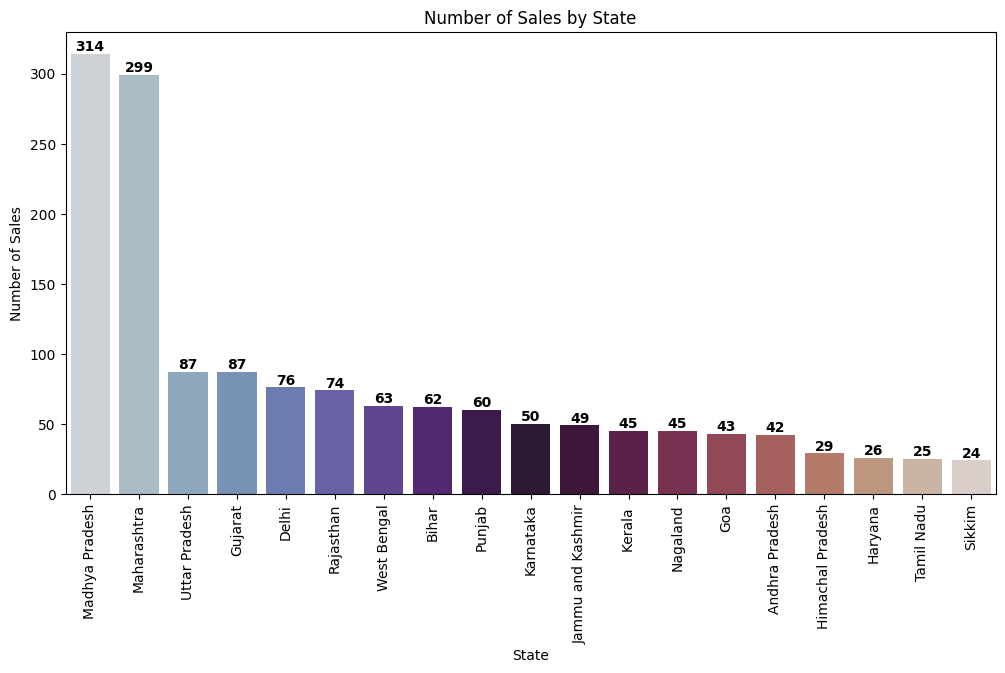

In [7]:
# Function to annotate bars
def annotate_bars(ax):
# Create the bar plot
    for p in ax.patches:
        ax.annotate(f"{p.get_height():,.0f}", 
                    (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# 1. Number of Sales by State
plt.figure(figsize=(12, 6))
sales_by_state = df['State'].value_counts()
ax = sns.barplot(x=sales_by_state.index, y=sales_by_state.values, palette='twilight',)
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Number of Sales")
plt.title("Number of Sales by State")

# Annotate bars
annotate_bars(ax)

plt.show()

/var/folders/s2/wrqnpqps029_g2jfhfjktscc0000gn/T/ipykernel_9772/3559708793.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=quantity_by_category.index, y=quantity_by_category.values, palette='coolwarm')


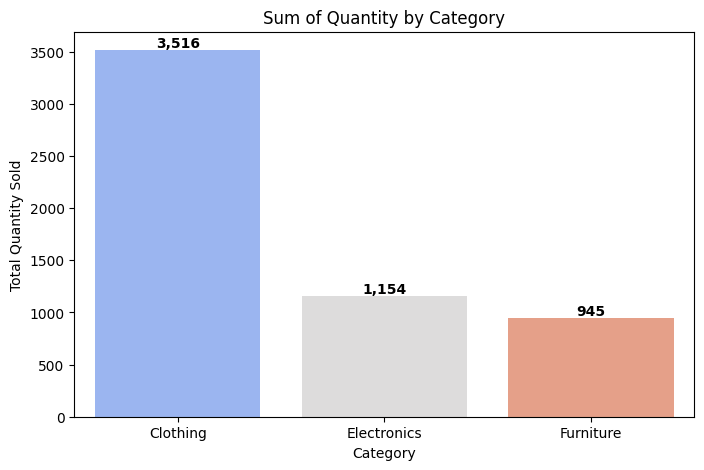

In [8]:
# 2. Sum of Quantity by Category
# Group by 'Category' and sum the 'Quantity'
quantity_by_category = df.groupby('Category')['Quantity'].sum()

# Create the bar plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=quantity_by_category.index, y=quantity_by_category.values, palette='coolwarm')

# Annotate bars with quantity values
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Labels and title
plt.xlabel("Category")
plt.ylabel("Total Quantity Sold")
plt.title("Sum of Quantity by Category")

plt.show()


         Sub-Category     City  Amount
18        Accessories     Pune    2822
39          Bookcases     Pune    6797
57             Chairs  Mathura    7844
78   Electronic Games   Mumbai   10113
91        Furnishings   Indore    2501
114       Hankerchief   Indore    2299
136             Kurti   Indore     717
157          Leggings   Indore     224
188            Phones     Pune    6890
210          Printers     Pune    9908
231             Saree   Mumbai    9393
245             Shirt   Indore    1656
265             Skirt   Indore     433
287             Stole   Indore    2989
314           T-shirt  Lucknow     846
325            Tables    Delhi    5985
351          Trousers   Mumbai    5287


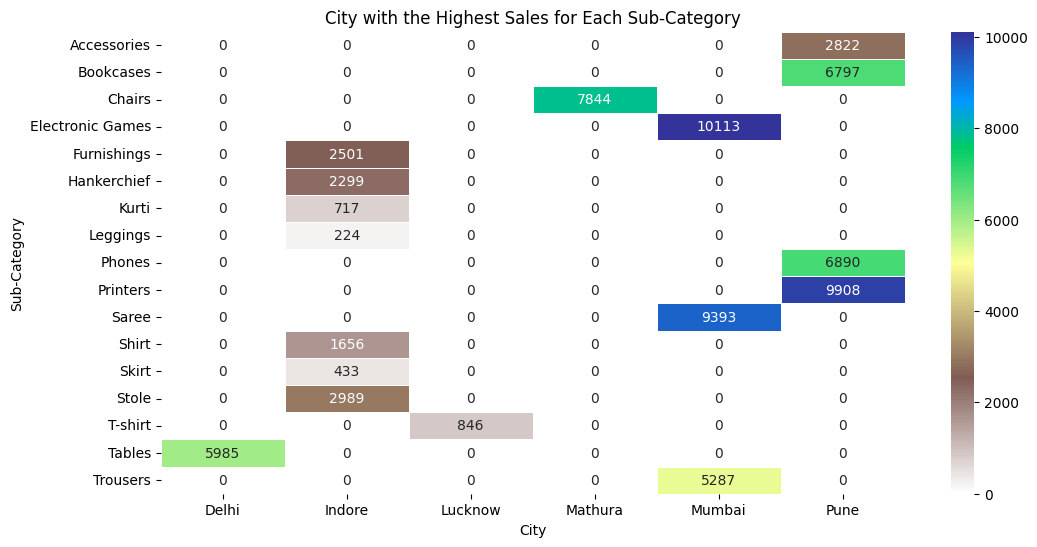

In [9]:
# 3. Group by 'City' and 'Sub-Category' to sum the sales amount
subcat_sales_by_city = df.groupby(['Sub-Category', 'City'])['Amount'].sum().reset_index()

# Find the city with the maximum sales for each sub-category
top_city_per_subcat = subcat_sales_by_city.loc[subcat_sales_by_city.groupby('Sub-Category')['Amount'].idxmax()]

# Display the results
print(top_city_per_subcat)

# Pivot the data for heatmap
heatmap_data = top_city_per_subcat.pivot(index="Sub-Category", columns="City", values="Amount").fillna(0)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='terrain_r', annot=True, fmt=".0f", linewidths=0.5)

plt.xlabel("City")
plt.ylabel("Sub-Category")
plt.title("City with the Highest Sales for Each Sub-Category")

plt.show()

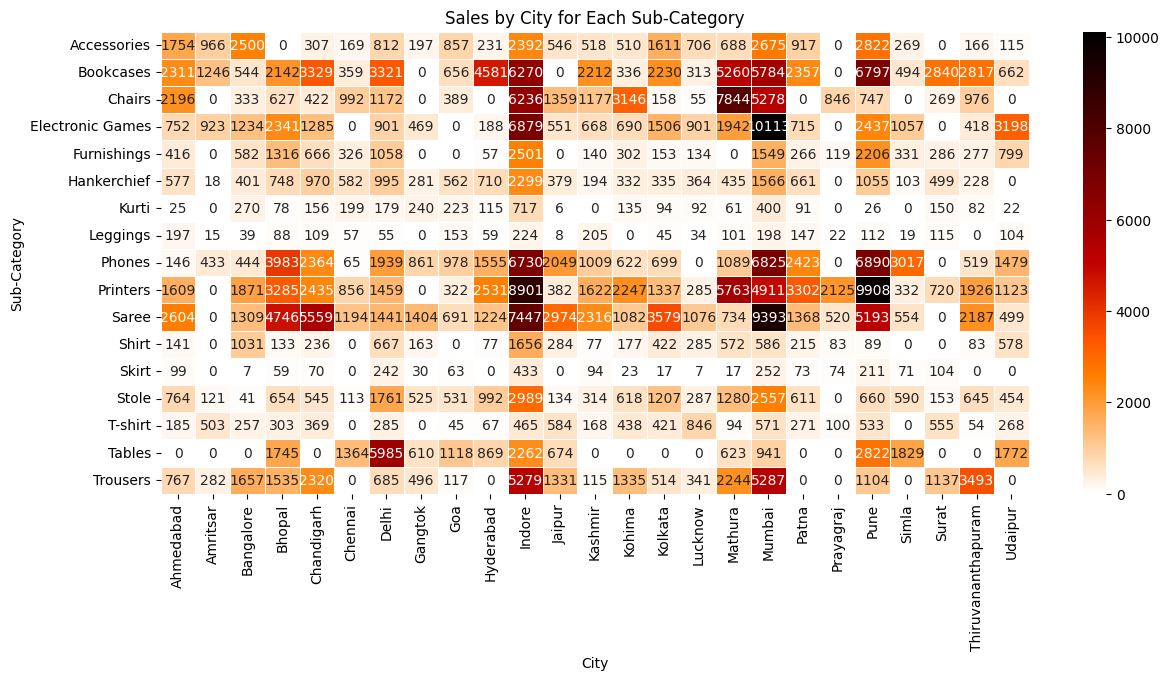

In [10]:
# 3. Group by 'City' and 'Sub-Category' to sum the sales amount
subcat_sales_by_city = df.groupby(['Sub-Category', 'City'])['Amount'].sum().reset_index()

# Pivot the data for heatmap (including all cities)
heatmap_data = subcat_sales_by_city.pivot(index="Sub-Category", columns="City", values="Amount").fillna(0)

# Plot heatmap with a different color palette
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='gist_heat_r', annot=True, fmt=".0f", linewidths=0.5)  # Change 'Blues' to other options
plt.xlabel("City")
plt.ylabel("Sub-Category")
plt.title("Sales by City for Each Sub-Category")

plt.show()

/var/folders/s2/wrqnpqps029_g2jfhfjktscc0000gn/T/ipykernel_9772/3141233497.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_3_cities_per_category = category_sales_by_city.groupby("Category").apply(lambda x: x.nlargest(3, 'Amount')).reset_index(drop=True)


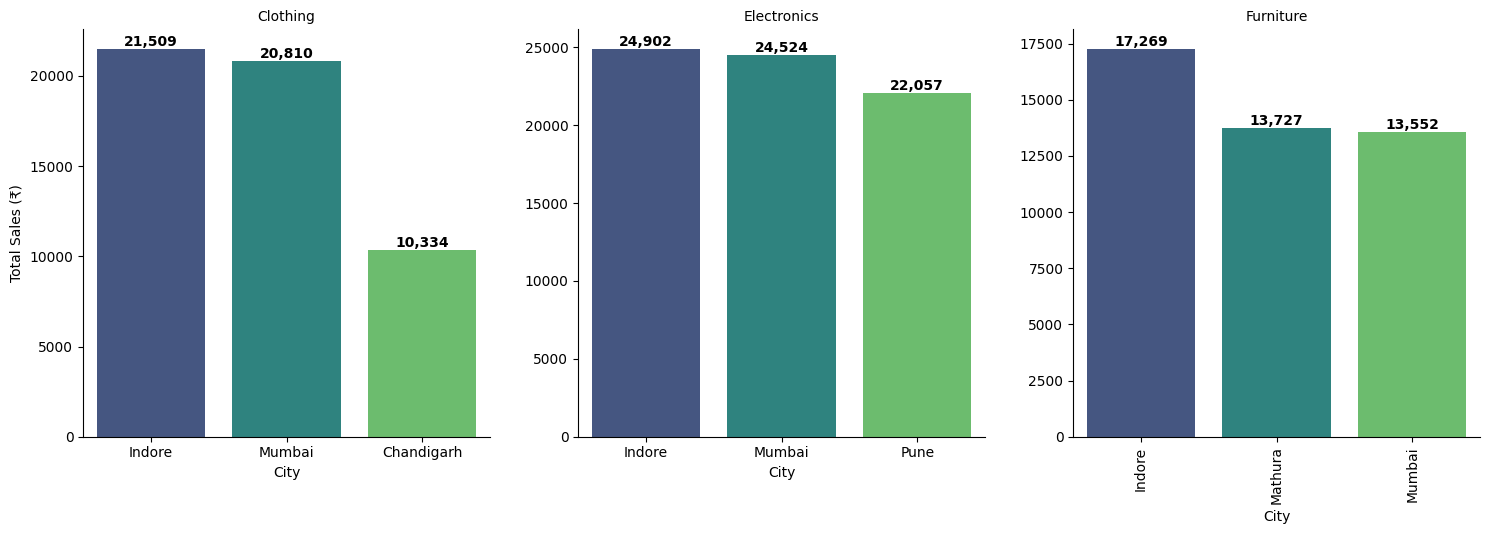

In [11]:
# Group by 'Category' and 'City' to sum the sales amount
category_sales_by_city = df.groupby(['Category', 'City'])['Amount'].sum().reset_index()

# Find the top 3 cities for each category
top_3_cities_per_category = category_sales_by_city.groupby("Category").apply(lambda x: x.nlargest(3, 'Amount')).reset_index(drop=True)

# Create FacetGrid
g = sns.FacetGrid(top_3_cities_per_category, col="Category", col_wrap=3, sharex=False, sharey=False, height=5)

# Function to annotate bars
def annotate_bars(ax):
    for p in ax.patches:
        ax.annotate(f"{p.get_height():,.0f}",  
                    (p.get_x() + p.get_width() / 2, p.get_height()),  
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot bar charts with annotations
def barplot_with_annotation(data, **kwargs):
    ax = sns.barplot(data=data, x="City", y="Amount",hue = "City", palette="viridis", **kwargs)
    annotate_bars(ax)

g.map_dataframe(barplot_with_annotation)

# Adjust the labels
g.set_axis_labels("City", "Total Sales (₹)")
g.set_titles("{col_name}")

plt.xticks(rotation=90)
plt.show()

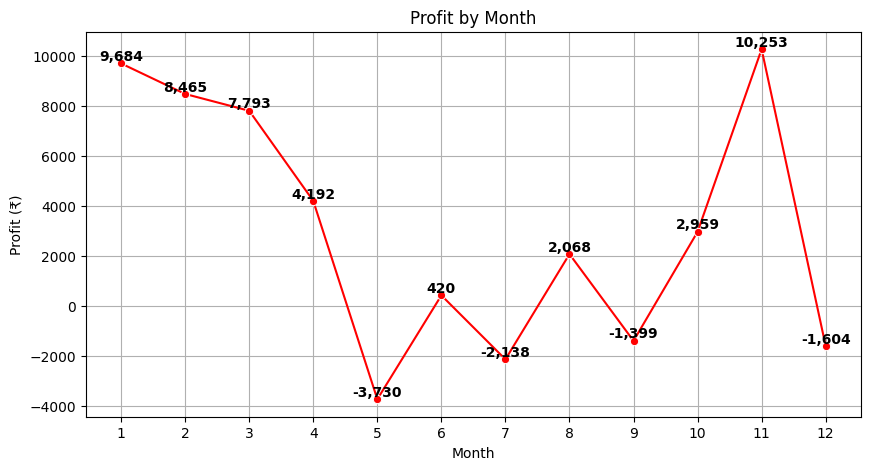

In [12]:
# 4. Profit by Month
# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract month
df['Month'] = df['Order Date'].dt.month

# Group by month and sum the profit
profit_by_month = df.groupby('Month')['Profit'].sum()

# Plot the profit by month
plt.figure(figsize=(10, 5))
sns.lineplot(x=profit_by_month.index, y=profit_by_month.values, marker='o', color='r')

# Annotate each point with profit value
for month, profit in profit_by_month.items():
    plt.text(month, profit, f"{profit:,.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Ensure all months from 1 to 12 are displayed
plt.xticks(range(1, 13))

plt.xlabel("Month")
plt.ylabel("Profit (₹)")
plt.title("Profit by Month")
plt.grid()
plt.show()

/var/folders/s2/wrqnpqps029_g2jfhfjktscc0000gn/T/ipykernel_9772/644116197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=profit_by_subcategory.index, y=profit_by_subcategory.values, palette='magma')


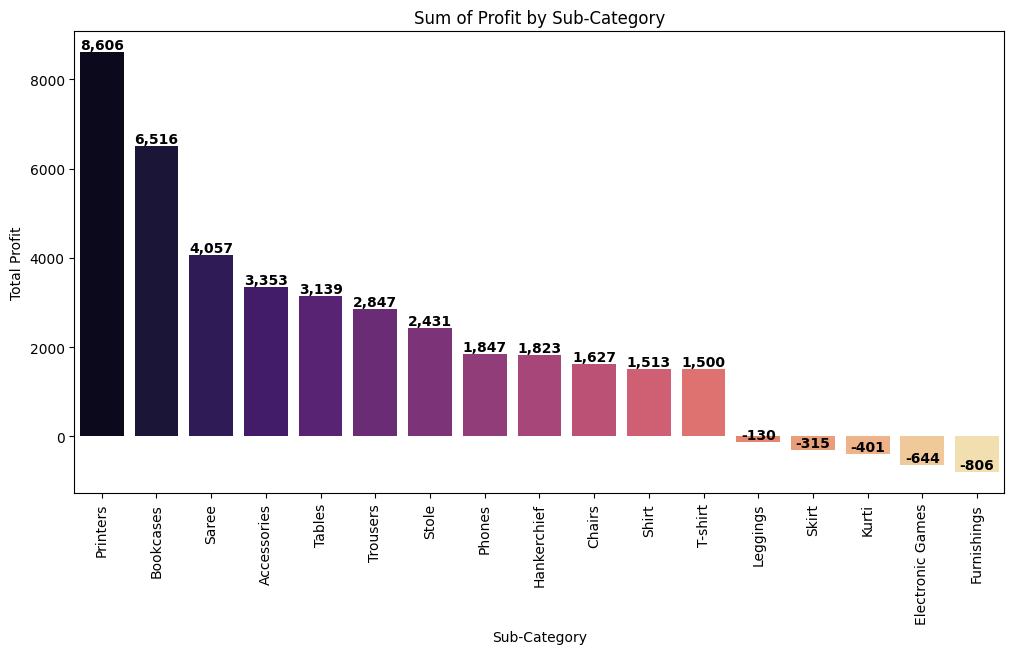

In [13]:
# 5. Sum of Profit by Sub-Category
profit_by_subcategory = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

# Create the figure
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=profit_by_subcategory.index, y=profit_by_subcategory.values, palette='magma')

# Annotate bars with exact profit values
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}",  # Format number with commas
                (p.get_x() + p.get_width() / 2, p.get_height()),  
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Set labels and title
plt.xticks(rotation=90)
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.title("Sum of Profit by Sub-Category")

# Show the plot
plt.show()

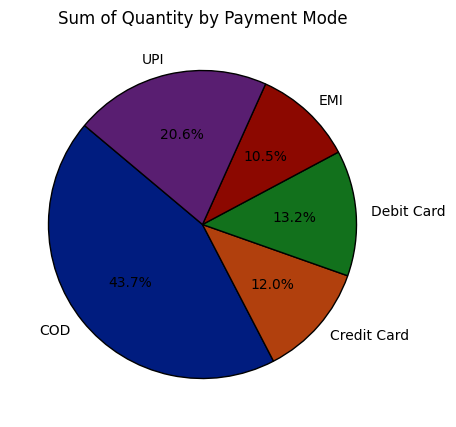

In [14]:


# 6. Sum of Quantity by Payment Mode (Pie Chart with Dark Colors)
quantity_by_payment = df.groupby('PaymentMode')['Quantity'].sum()

# Create the figure
plt.figure(figsize=(8, 5))
plt.pie(quantity_by_payment, labels=quantity_by_payment.index, autopct='%1.1f%%', 
        colors=sns.color_palette("dark"), startangle=140, wedgeprops={'edgecolor': 'black'})

# Set title
plt.title("Sum of Quantity by Payment Mode")

# Show the plot
plt.show()

In [15]:
# 7. Total Profit, Total Sales, Total Quantity
total_profit = df['Profit'].sum()
total_sales = df['Amount'].sum()
total_quantity = df['Quantity'].sum()


In [16]:
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity}")


Total Profit: ₹36,963.00
Total Sales: ₹437,771.00
Total Quantity Sold: 5615


# ------------------- MACHINE LEARNING: LOGISTIC REGRESSION -------------------


In [17]:
# Create a binary classification target: High Sales (1) / Low Sales (0)
#It checks if the ‘Amount’ (sales value) is greater than the median amount.
df['High_Sales'] = (df['Amount'] > df['Amount'].median()).astype(int)


In [18]:
#	•	X (input data) contains ‘Quantity’ and ‘Profit’.
#	•	y (output labels) contains 1 for High Sales and 0 for Low Sales.
features = ['Quantity', 'Profit']
X = df[features]
y = df['High_Sales']


In [19]:
# Train-Test Split
#	•	Splits the data 80% for training and 20% for testing.
#	•	random_state=42 ensures results are consistent every time you run it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
# Train Logistic Regression Model
#	•	Uses Logistic Regression, a simple classification algorithm.
#	•	The model learns the relationship between Quantity, Profit, and High Sales.
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [21]:
# Predictions
y_pred = model.predict(X_test)
y_pred


array([1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0])

In [22]:

# • Accuracy: How many total predictions were correct?
# •	Precision: When the model predicts High Sales (1), how often is it correct?##
accuracy=accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)


In [23]:
# Print evaluation metrics
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy * 100:.2f} %")
print(f"Precision: {precision * 100:.2f} %")



--- Model Evaluation ---
Accuracy: 60.33 %
Precision: 61.11 %


In [24]:
# Now predict sales growth for 2024 using 2023 and 2024 data
# Filter data for 2023 and 2024
df_2023 = df[df['Order Date'].dt.year == 2023]
df_2024 = df[df['Order Date'].dt.year == 2024]

# Check if there's any data for 2024
if len(df_2024) == 0:
    print("No data for 2024 to predict.")
else:
    # Prepare features for 2024
    X_2024 = df_2024[features]

    # Use the trained model to predict high sales for 2024
    y_pred_2024 = model.predict(X_2024)

    # Add predicted high sales for the 2024 data
    df_2024['Predicted_High_Sales'] = y_pred_2024

    # Calculate total sales for 2023 and predicted sales for 2024
    total_sales_2023 = df_2023['Amount'].sum()
    total_sales_2024_predicted = df_2024[df_2024['Predicted_High_Sales'] == 1]['Amount'].sum()

    # Calculate sales growth percentage
    if total_sales_2023 > 0:  # Avoid division by zero
        sales_growth = ((total_sales_2024_predicted - total_sales_2023) / total_sales_2023) * 100
    else:
        sales_growth = 0  # Set to 0 if sales in 2023 are zero

    # Print Sales Growth
    print(f"Sales Growth Prediction for 2024 (vs 2023): {sales_growth:.2f} %")

Sales Growth Prediction for 2024 (vs 2023): -38.13 %


/var/folders/s2/wrqnpqps029_g2jfhfjktscc0000gn/T/ipykernel_9772/611303650.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['Predicted_High_Sales'] = y_pred_2024
